In [16]:
import numpy as onp
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from pathlib import Path
import sys
_project_root: Path = Path.cwd().resolve()
sys.path.insert(0, str(_project_root.parents[1]))

In [31]:
# vacuum speed of light
C = 1.0
# refractive indices
n_0 = 1.0
n_h20 = 1.333
n_g = 1.458

def R(θ):
  return onp.array([
    [ onp.cos(θ), -onp.sin(θ)],
    [+onp.sin(θ),  onp.cos(θ)],
  ])

# angle to normal
θ_I = onp.pi / 3
k_I = R(θ_I) @ onp.array([-1, 0])
θ_g = onp.arcsin(n_0 / n_g * onp.sin(θ_I))
k_g = R(θ_g) @ onp.array([1, 0])
print(onp.arccos(onp.dot(k_g, onp.array([1, 0]))) - θ_g)
θ_h20 = onp.arcsin(n_0 / n_h20 * onp.sin(θ_I))
k_h20 = R(θ_h20) @ onp.array([1, 0])


0.0


**Expect to see:** light bends more (a smaller angle w.r.t. the normal) in glass since glass has a higher refractive index. 

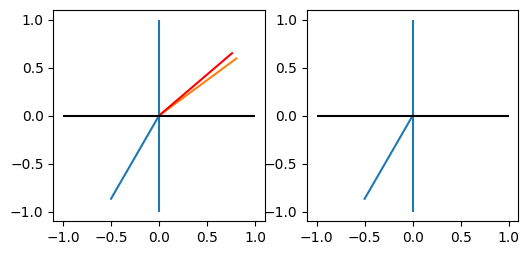

In [ ]:
fig, _axs = plt.subplots(1, 2, figsize=(6,8))
axs: list[Axes] = onp.array(_axs).tolist()
ts = onp.linspace(0, 1, 100)
ray_I = ts[:, None] * k_I
ray_g = ts[:, None] * k_g
ray_h20 = ts[:, None] * k_h20
axs[0].plot(ray_I[:, 0], ray_I[:, 1])
axs[0].plot(ray_g[:, 0], ray_g[:, 1])
axs[0].plot(ray_h20[:, 0], ray_h20[:, 1], color='red')
axs[0].vlines(0, -1, 1)
axs[0].hlines(0, -1, 1, color='k')
axs[0].set(aspect='equal')

axs[1].plot(ray_I[:, 0], ray_I[:, 1])
axs[1].vlines(0, -1, 1)
axs[1].hlines(0, -1, 1, color='k')
axs[1].set(aspect='equal')
plt.show();

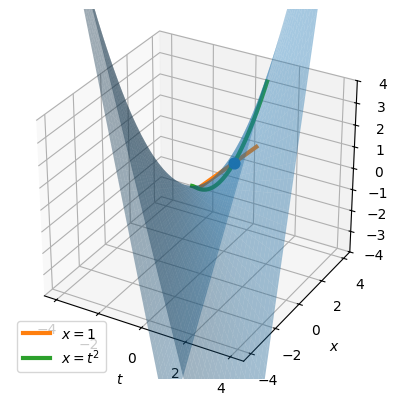

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Surface z = t*x
t = np.linspace(-4, 4, 100)
x = np.linspace(-4, 4, 100)
T, X = np.meshgrid(t, x)
Z = T * X

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(T, X, Z, alpha=0.4)

# Hold x = 1 fixed: (t, 1, t)
s = np.linspace(-0.5, 2, 300)
ax.plot(s, np.ones_like(s), s, linewidth=3, label=r"$x=1$")

# Follow x = t^2: (t, t^2, t^3)
s = np.linspace(-0.5, 1.6, 300)
ax.plot(s, s**2, s**3, linewidth=3, label=r"$x=t^2$")

ax.scatter([1], [1], [1], s=60)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$x$")
ax.set_zlabel(r"$f(t,x)$")
ax.set(zlim=(-4,4))
ax.set(aspect='equal')
ax.legend()
plt.show()

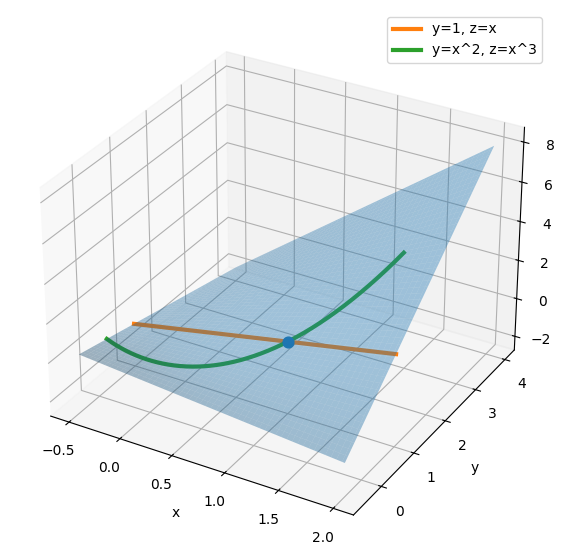

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Surface z = x*y
x = np.linspace(-0.5, 2, 100)
y = np.linspace(-0.5, 4, 100)
X, Y = np.meshgrid(x, y)
Z = X * Y

fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, alpha=0.4)

# Partial-derivative path: y = 1, z = x
t = np.linspace(-0.5, 2, 300)
ax.plot(t, np.ones_like(t), t, linewidth=3, label='y=1, z=x')

# Composite path: y = x^2, z = x^3
t2 = np.linspace(-0.5, 1.6, 300)
ax.plot(t2, t2**2, t2**3, linewidth=3, label='y=x^2, z=x^3')

# Common point
ax.scatter([1], [1], [1], s=60)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()
plt.show()